# Sentiment-Enhanced Stock Price Prediction
## TRAIN PHASE ONLY — Train 3 Model Types (DLinear, NODE, Hybrid)

Notebook này chỉ chạy **TRAIN** — train model và lưu `.pt` + `.pkl` scaler vào `LOGS/DLINEAR+NODE/`

## CELL 1: Setup & Config

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import glob
import json
import warnings
import random
import matplotlib.dates as mdates
from IPython.display import display
import pickle

# ─────────────────────────────────────────────
# Hàm metrics bổ trợ
# ─────────────────────────────────────────────
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def calculate_da(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    return np.mean((true_diff * pred_diff) > 0) * 100

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ─────────────────────────────────────────────
# Random Seed
# ─────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# HYPERPARAMETERS
# ─────────────────────────────────────────────
SEQ_LEN    = 100
HIDDEN_DIM = 128
DROPOUT    = 0.2
EPOCHS     = 150
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Hyperparameters riêng cho Sentiment model
SENTIMENT_EPOCHS       = 200
SENTIMENT_HIDDEN_DIM   = 256
SENTIMENT_DROPOUT      = 0.1
SENTIMENT_LEARNING_RATE = 0.0005

FUTURE_DAYS = 5   # số ngày tương lai cần dự báo

# ─────────────────────────────────────────────
# MODEL TYPES: Train cả 3 mô hình
# ─────────────────────────────────────────────
MODEL_TYPES = ['dlinear', 'node', 'hybrid']

# ─────────────────────────────────────────────
# ĐÂY LÀ PHẦN BẠN CẦN CHỈNH — 3 ĐƯỜNG DẪN
# ─────────────────────────────────────────────
BASE_DIR = os.path.join("..", "..", "DATASET")   # <-- thay đổi nếu cần

TRAIN_PRICE_DIR     = os.path.join(BASE_DIR, "TRAIN", "PRICE")
TRAIN_SENTIMENT_DIR = os.path.join(BASE_DIR, "TRAIN", "SENTIMENT")

# Thư mục lưu chart & log
CHART_DIR = os.path.join("..", "..", "CHART", "DLINEAR+NODE")
LOG_DIR   = os.path.join("..", "..", "LOGS",  "DLINEAR+NODE")
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(LOG_DIR,   exist_ok=True)

print("\n=== CẤU HÌNH ĐƯỜNG DẪN ===")
print(f"  TRAIN PRICE     : {os.path.abspath(TRAIN_PRICE_DIR)}")
print(f"  TRAIN SENTIMENT : {os.path.abspath(TRAIN_SENTIMENT_DIR)}")
print(f"  CHART DIR       : {os.path.abspath(CHART_DIR)}")
print(f"  LOG   DIR       : {os.path.abspath(LOG_DIR)}")
print(f"\n[INFO] Model Types to train: {MODEL_TYPES}")

Using device: cpu

=== CẤU HÌNH ĐƯỜNG DẪN ===
  TRAIN PRICE     : d:\NghienCuu\NCT3\DATASET\TRAIN\PRICE
  TRAIN SENTIMENT : d:\NghienCuu\NCT3\DATASET\TRAIN\SENTIMENT
  CHART DIR       : d:\NghienCuu\NCT3\CHART\DLINEAR+NODE
  LOG   DIR       : d:\NghienCuu\NCT3\LOGS\DLINEAR+NODE

[INFO] Model Types to train: ['dlinear', 'node', 'hybrid']


## CELL 2: Model Architecture (3 types)

In [8]:
class SentimentDLinearNodeModel(nn.Module):
    def __init__(self, seq_len=100, price_dim=5, sentiment_dim=10, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.seq_len      = seq_len
        self.price_dim    = price_dim
        self.sentiment_dim = sentiment_dim

        # DLinear cho Price
        self.price_decomp = nn.Sequential(
            nn.Linear(seq_len, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, seq_len)
        )
        # DLinear cho Sentiment
        self.sentiment_decomp = nn.Sequential(
            nn.Linear(seq_len, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, seq_len)
        )
        # NODE (Neural ODE Approximation)
        self.node_layers = nn.Sequential(
            nn.Linear(price_dim + sentiment_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, price_dim + sentiment_dim)
        )
        # Predictor
        self.predictor = nn.Sequential(
            nn.Linear((price_dim + sentiment_dim) * seq_len, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, price_x, sentiment_x):
        batch_size, seq_len, _ = price_x.shape
        combined_input   = torch.cat([price_x, sentiment_x], dim=-1)
        price_trend      = self.price_decomp(price_x.transpose(1, 2)).transpose(1, 2)
        sentiment_trend  = self.sentiment_decomp(sentiment_x.transpose(1, 2)).transpose(1, 2)
        combined_trend   = torch.cat([price_trend, sentiment_trend], dim=-1)
        node_output      = combined_input + self.node_layers(combined_input)
        final_features   = combined_trend + node_output
        return self.predictor(final_features.reshape(batch_size, -1))

print("Model SentimentDLinearNodeModel đã được định nghĩa.")

# ─────────────────────────────────────────────
# MODEL 2: DLinear Only (Price Only)
# ─────────────────────────────────────────────
class SentimentDLinearModel(nn.Module):
    """DLinear Model: Chỉ sử dụng Price (KHÔNG dùng Sentiment)"""
    def __init__(self, seq_len=100, price_dim=5, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.seq_len   = seq_len
        self.price_dim = price_dim

        # DLinear cho Price
        self.price_decomp = nn.Sequential(
            nn.Linear(seq_len, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, seq_len)
        )
        # Predictor
        self.predictor = nn.Sequential(
            nn.Linear(price_dim * seq_len, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, price_x, sentiment_x=None):
        batch_size, seq_len, _ = price_x.shape
        price_trend = self.price_decomp(price_x.transpose(1, 2)).transpose(1, 2)
        return self.predictor(price_trend.reshape(batch_size, -1))

print("Model SentimentDLinearModel đã được định nghĩa.")

# ─────────────────────────────────────────────
# MODEL 3: NODE Only (Price Only)
# ─────────────────────────────────────────────
class SentimentNODEModel(nn.Module):
    """NODE Model: Chỉ sử dụng Price (KHÔNG dùng Sentiment)"""
    def __init__(self, seq_len=100, price_dim=5, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.seq_len   = seq_len
        self.price_dim = price_dim

        # NODE (Neural ODE Approximation)
        self.node_layers = nn.Sequential(
            nn.Linear(price_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, price_dim)
        )
        # Predictor
        self.predictor = nn.Sequential(
            nn.Linear(price_dim * seq_len, hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, price_x, sentiment_x=None):
        batch_size, seq_len, _ = price_x.shape
        node_output = price_x + self.node_layers(price_x)
        return self.predictor(node_output.reshape(batch_size, -1))

print("Model SentimentNODEModel đã được định nghĩa.")

# ─────────────────────────────────────────────
# Factory Function
# ─────────────────────────────────────────────
def get_model_by_type(model_type, seq_len=100, price_dim=5, sentiment_dim=10, hidden_dim=128, dropout=0.2):
    if model_type == 'dlinear':
        return SentimentDLinearModel(seq_len=seq_len, price_dim=price_dim, hidden_dim=hidden_dim, dropout=dropout)
    elif model_type == 'node':
        return SentimentNODEModel(seq_len=seq_len, price_dim=price_dim, hidden_dim=hidden_dim, dropout=dropout)
    elif model_type == 'hybrid':
        return SentimentDLinearNodeModel(seq_len=seq_len, price_dim=price_dim, sentiment_dim=sentiment_dim, hidden_dim=hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

print("Factory function get_model_by_type() đã sẵn sàng.")

Model SentimentDLinearNodeModel đã được định nghĩa.
Model SentimentDLinearModel đã được định nghĩa.
Model SentimentNODEModel đã được định nghĩa.
Factory function get_model_by_type() đã sẵn sàng.


## CELL 3: DataProcessor

In [9]:
class DataProcessor:
    def __init__(self):
        self.price_scaler = None
        self.sentiment_scaler = None
        self.target_scaler = None

    def clean_numeric_value(self, value):
        """
        Chuyển đổi giá trị có đơn vị (69.84M, 1.5K, v.v.) thành số thập phân
        '69.84M' → 69840000
        '1.5K' → 1500
        '100' → 100
        """
        if pd.isna(value):
            return np.nan
        
        value = str(value).strip().upper()
        
        # Nếu là số thường
        try:
            return float(value)
        except:
            pass
        
        # Xử lý các đơn vị
        multipliers = {
            'K': 1_000,
            'M': 1_000_000,
            'B': 1_000_000_000,
            'L': 100_000,  # Lakh (Ấn Độ)
            'E': 1  # Nếu E là phần trăm hoặc đơn vị khác, điều chỉnh theo cần
        }
        
        for unit, multiplier in multipliers.items():
            if unit in value:
                try:
                    num_part = value.replace(unit, '').strip()
                    return float(num_part) * multiplier
                except:
                    return np.nan
        
        return np.nan

    def standardize_date_format(self, df, date_col='Date'):
        """
        Standardize date column to DD/MM/YYYY format
        Handles multiple input formats: YYYY-MM-DD, DD/MM/YYYY, MM/DD/YYYY, etc.
        """
        if date_col not in df.columns:
            return df
        
        # Try to parse dates with dayfirst=True (for DD/MM/YYYY format)
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
        
        # Format as DD/MM/YYYY string
        df[date_col] = df[date_col].dt.strftime('%d/%m/%Y')
        
        print(f"    [DATE] Standardized to DD/MM/YYYY format")
        print(f"    [DATE] Sample dates: {df[date_col].head(3).values}")
        
        return df

    def load_and_merge_data(self, price_path, sentiment_path):
        """
        Load price CSV + sentiment CSV and merge on Date column.
        NOTE: Date handling is done manually by user - dates must already be synchronized.
        """
        price_df = pd.read_csv(price_path,     encoding='utf-8-sig')
        sent_df  = pd.read_csv(sentiment_path, encoding='utf-8-sig')

        # Normalize Date column name (handles DATE/date variations)
        price_date_col = next((c for c in price_df.columns if c.lower() == 'date'), None)
        sent_date_col = next((c for c in sent_df.columns if c.lower() == 'date'), None)
        if price_date_col and price_date_col != 'Date':
            price_df = price_df.rename(columns={price_date_col: 'Date'})
        if sent_date_col and sent_date_col != 'Date':
            sent_df = sent_df.rename(columns={sent_date_col: 'Date'})

        # Ensure Date column exists and dates are already in matching format
        if 'Date' not in price_df.columns:
            print(" WARNING: 'Date' column not found in price file")
        if 'Date' not in sent_df.columns:
            print(" WARNING: 'Date' column not found in sentiment file")

        # Standardize date format to DD/MM/YYYY
        price_df = self.standardize_date_format(price_df, 'Date')
        sent_df = self.standardize_date_format(sent_df, 'Date')

        # Remove NaN dates if they exist, then sort by real datetime
        price_df = price_df.dropna(subset=['Date']).drop_duplicates('Date')
        price_df['Date_dt'] = pd.to_datetime(price_df['Date'], format='%d/%m/%Y', errors='coerce')
        price_df = price_df.dropna(subset=['Date_dt']).sort_values('Date_dt').drop(columns=['Date_dt'])

        sent_df = sent_df.dropna(subset=['Date'])

        # Aggregate sentiment by extracting numeric cols
        sent_cols_to_process = [c for c in sent_df.columns if any(
            w in c.lower() for w in ['score', 'impact', 'relevance', 'sentiment',
                                     'confidence', 'momentum', 'volatility', 'prob'])]
        
        # ✅ DEBUG: In sentiment columns tìm được
        print(f"    [DEBUG] Sentiment columns found in raw file: {sent_cols_to_process}")
        print(f"    [DEBUG] All sentiment columns: {list(sent_df.columns)}")
        
        for col in sent_cols_to_process:
            sent_df[col] = pd.to_numeric(sent_df[col], errors='coerce')
        sent_df = sent_df.groupby('Date')[sent_cols_to_process].mean().reset_index()
        sent_df['Date_dt'] = pd.to_datetime(sent_df['Date'], format='%d/%m/%Y', errors='coerce')
        sent_df = sent_df.dropna(subset=['Date_dt']).sort_values('Date_dt').drop(columns=['Date_dt'])

        print(f" THỐNG KÊ FILE GỐC:")
        print(f"   Price     : {len(price_df)} dòng")
        print(f"   Sentiment : {len(sent_df)} dòng")
        print(f"   Sentiment columns after merge: {[c for c in sent_df.columns if c != 'Date']}")

        # Merge on Date (dates must already be synchronized)
        merged_df = pd.merge(price_df, sent_df, on='Date', how='left')
        merged_df['Date_dt'] = pd.to_datetime(merged_df['Date'], format='%d/%m/%Y', errors='coerce')
        merged_df = merged_df.dropna(subset=['Date_dt']).sort_values('Date_dt').drop(columns=['Date_dt'])
        return merged_df

    def create_features(self, df):
        """Extract price and sentiment features from merged DataFrame"""
        # Price features: numeric columns except Date
        price_cols = [c for c in df.columns if c != 'Date' and 
                     not any(w in c.lower() for w in ['score', 'impact', 'relevance', 'sentiment', 
                                                       'confidence', 'momentum', 'volatility', 'prob'])]
        
        # Sentiment features: numeric columns with sentiment keywords
        sentiment_cols = [c for c in df.columns if c != 'Date' and 
                         any(w in c.lower() for w in ['score', 'impact', 'relevance', 'sentiment',
                                                       'confidence', 'momentum', 'volatility', 'prob'])]
        
        # Use 'Close' or 'close' as target if available
        target_col = next((c for c in df.columns if c.lower() == 'close'), None)
        
        # ✅ XỬ LÝ GIẢI PHÓNG GIỐNG NHƯ 69.84M, 1.5K, V.V.
        price_df_clean = df[price_cols].copy()
        for col in price_cols:
            price_df_clean[col] = price_df_clean[col].apply(self.clean_numeric_value)
        
        sentiment_df_clean = df[sentiment_cols].copy()
        for col in sentiment_cols:
            sentiment_df_clean[col] = sentiment_df_clean[col].apply(self.clean_numeric_value)
        
        if target_col:
            target_series = df[target_col].apply(self.clean_numeric_value)
        else:
            target_series = price_df_clean[price_cols[0]].copy()
        
        price_feats = price_df_clean.fillna(0).values
        sentiment_feats = sentiment_df_clean.fillna(0).values if sentiment_cols else np.zeros((len(df), 1))
        targets = target_series.fillna(0).values
        
        print(f"    [DEBUG] Price features shape: {price_feats.shape}, Target shape: {targets.shape}")
        
        return price_feats, sentiment_feats, targets

    def prepare_sequences(self, price_feats, sentiment_feats, targets, stock_name='', seq_len=100, fit=False):
        """Create sequences for LSTM/transformer models"""
        if fit:
            self.price_scaler = StandardScaler()
            self.sentiment_scaler = StandardScaler()
            self.target_scaler = StandardScaler()
            
            price_feats = self.price_scaler.fit_transform(price_feats)
            sentiment_feats = self.sentiment_scaler.fit_transform(sentiment_feats)
            targets = self.target_scaler.fit_transform(targets.reshape(-1, 1)).flatten()
        else:
            price_feats = self.price_scaler.transform(price_feats)
            sentiment_feats = self.sentiment_scaler.transform(sentiment_feats)
            targets = self.target_scaler.transform(targets.reshape(-1, 1)).flatten()
        
        X_p = np.array([price_feats[i:i+seq_len] for i in range(len(price_feats)-seq_len)])
        X_s = np.array([sentiment_feats[i:i+seq_len] for i in range(len(sentiment_feats)-seq_len)])
        y = targets[seq_len:]
        
        return X_p, X_s, y

print("[DONE] DataProcessor class - Date format fixed (dayfirst=True)")

[DONE] DataProcessor class - Date format fixed (dayfirst=True)


## CELL 4: Metrics & Utilities

In [10]:
def get_performance_metrics(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2    = r2_score(y_true, y_pred)
    true_diff = np.diff(y_true)
    pred_diff = y_pred[1:] - y_true[:-1]
    da    = np.mean((true_diff * pred_diff) > 0) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R2": r2, "DA (%)": da}


def train_model(model, train_loader, val_loader, stock_name,
                epochs=150, is_sentiment=False, learning_rate=None):
    if learning_rate is None:
        learning_rate = SENTIMENT_LEARNING_RATE if is_sentiment else LEARNING_RATE

    optimizer  = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-6, threshold=1e-4)
    criterion  = nn.MSELoss()
    history    = {"train_loss": [], "val_loss": []}
    best_val   = float('inf')
    patience_counter = 0
    best_epoch = 0
    patience   = 25

    mode_name = "Sentiment Mode" if is_sentiment else "Hybrid Mode"
    print(f"Training {stock_name} ({mode_name})...")

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for p, s, y in train_loader:
            p, s, y = p.to(DEVICE), s.to(DEVICE), y.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(p, s), y)
            loss.backward(); optimizer.step()
            train_loss += loss.item()

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for p, s, y in val_loader:
                p, s, y = p.to(DEVICE), s.to(DEVICE), y.to(DEVICE).unsqueeze(1)
                v_loss += criterion(model(p, s), y).item()

        tl = train_loss / len(train_loader)
        vl = v_loss    / len(val_loader)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        scheduler.step(vl)

        if vl < best_val - 1e-4:
            best_val = vl; patience_counter = 0; best_epoch = epoch
        else:
            patience_counter += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} - Train: {tl:.6f}, Val: {vl:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})")
            break

    # stock_name format: {ticker_core}_{model_type}
    save_path = os.path.join(LOG_DIR, f"{stock_name}.pt")
    torch.save(model.state_dict(), save_path)
    print(f"  Model saved -> {save_path}")
    return history, save_path


def visualize_prediction(model, X_p_tensor, X_s_tensor, y_tensor,
                          stock_name, dates, mode, filename, processor):
    model.eval()
    with torch.no_grad():
        preds_scaled   = model(X_p_tensor.to(DEVICE), X_s_tensor.to(DEVICE)).squeeze().cpu().numpy()
        targets_scaled = y_tensor.cpu().numpy()
        predictions = processor.target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        targets     = processor.target_scaler.inverse_transform(targets_scaled.reshape(-1, 1)).flatten()

    plot_dates  = pd.to_datetime(dates, format='%d/%m/%Y', errors='coerce')
    source_name = filename.replace('.csv', '')
    date_fmt    = mdates.DateFormatter('%d/%m')

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.25)

    axes[0, 0].plot(plot_dates, targets,     label='Actual', color='blue', alpha=0.5, linewidth=1)
    axes[0, 0].plot(plot_dates, predictions, label='Forecast',  color='red',  linestyle='--', alpha=0.8)
    axes[0, 0].set_title(f'Overall Forecast ({stock_name}) - {mode}')
    axes[0, 0].xaxis.set_major_formatter(date_fmt)
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].scatter(targets, predictions, alpha=0.5, color='purple', s=10)
    axes[0, 1].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'k--', lw=1)
    axes[0, 1].set_title('Actual vs Forecast Correlation')
    axes[0, 1].set_xlabel('Actual Price'); axes[0, 1].set_ylabel('Forecast Price')

    last_n = 5
    axes[1, 0].plot(plot_dates[-last_n:], targets[-last_n:],     marker='o', label='Actual', color='blue')
    axes[1, 0].plot(plot_dates[-last_n:], predictions[-last_n:], marker='x', label='Forecast',  color='red', linestyle='--')
    axes[1, 0].set_title(f'Last {last_n} Days')
    axes[1, 0].xaxis.set_major_formatter(date_fmt)
    axes[1, 0].legend(); axes[1, 0].grid(True)

    error_pct = np.abs((targets - predictions) / (targets + 1e-9)) * 100
    axes[1, 1].bar(plot_dates[-20:], error_pct[-20:], color='orange', alpha=0.6)
    axes[1, 1].set_title('Error (%) - Last 20 Days')
    axes[1, 1].xaxis.set_major_formatter(date_fmt)
    axes[1, 1].set_ylabel('% Error')

    fig.autofmt_xdate()
    plot_filename = f"{source_name}_{mode}_2x2.png"
    plt.savefig(os.path.join(CHART_DIR, plot_filename), bbox_inches='tight', dpi=150)
    plt.show(); plt.close(fig)

    m = get_performance_metrics(targets, predictions)
    return {
        "Ticker": stock_name, "Mode": mode,
        "MSE": m["MSE"], "RMSE": m["RMSE"], "MAE": m["MAE"],
        "MAPE (%)": m["MAPE (%)"], "R2": m["R2"], "DA (%)": m["DA (%)"],
        "Actual Last": targets[-1], "Pred Last": predictions[-1]
    }

print("[DONE] Hàm utilities (train_model, visualize_prediction, get_performance_metrics) đã sẵn sàng")

[DONE] Hàm utilities (train_model, visualize_prediction, get_performance_metrics) đã sẵn sàng


## CELL 5: TRAIN LOOP - Train 3 Model Types


STARTING TRAIN PHASE

────────────────────────────────────────────────────────────────────────────────
MODEL TYPE: DLINEAR
────────────────────────────────────────────────────────────────────────────────
Found 6 training files

  Processing: ALIBABA (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['19/09/2014' '22/09/2014' '23/09/2014']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['01/01/1970' '01/01/1970' '01/01/1970']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 2587 dòng
   Sen

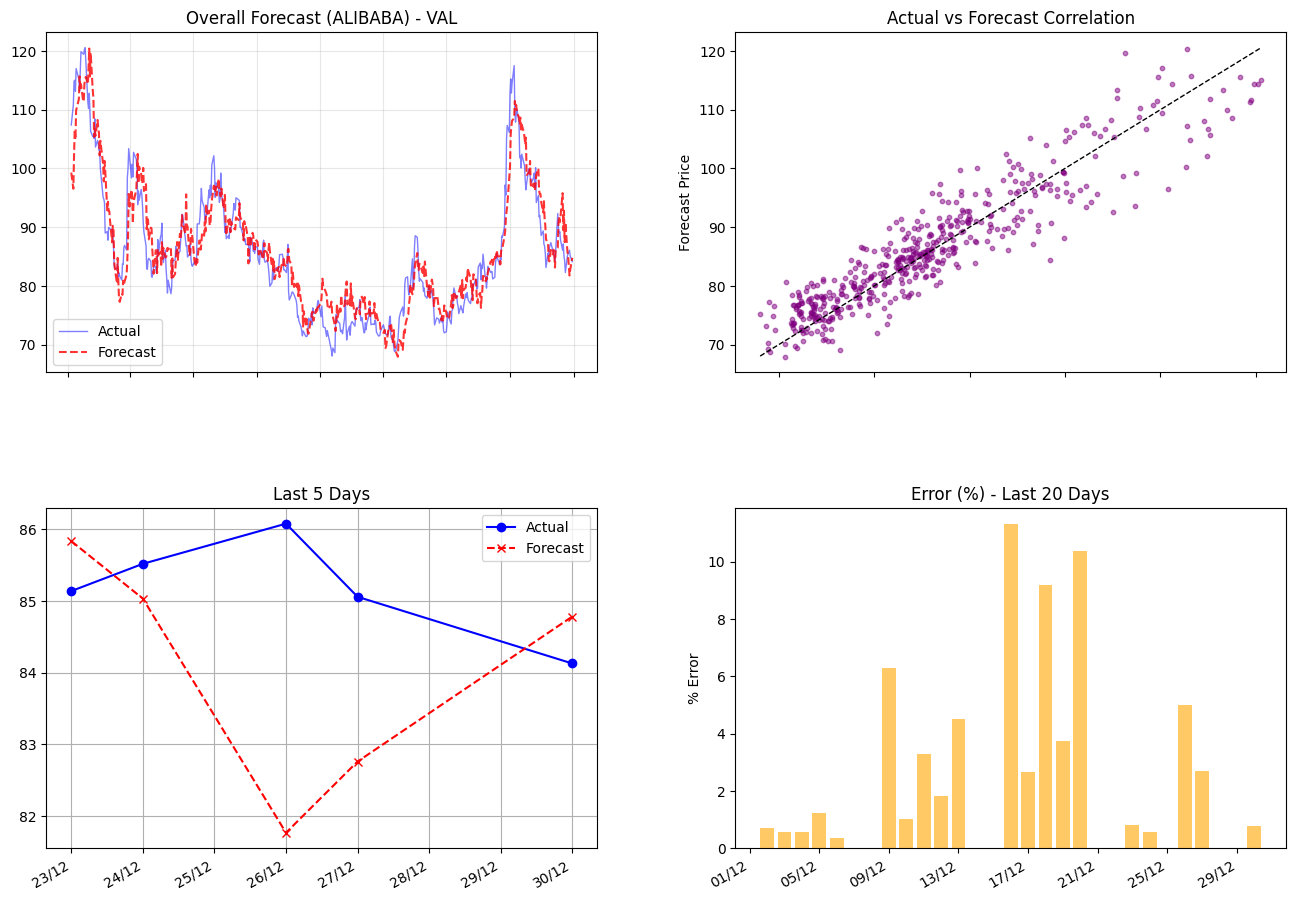

    Metrics: R2=0.8576, RMSE=4.2300

  Processing: AMAZON (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['05/08/2023' '05/08/2023' '05/08/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 718 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentimen

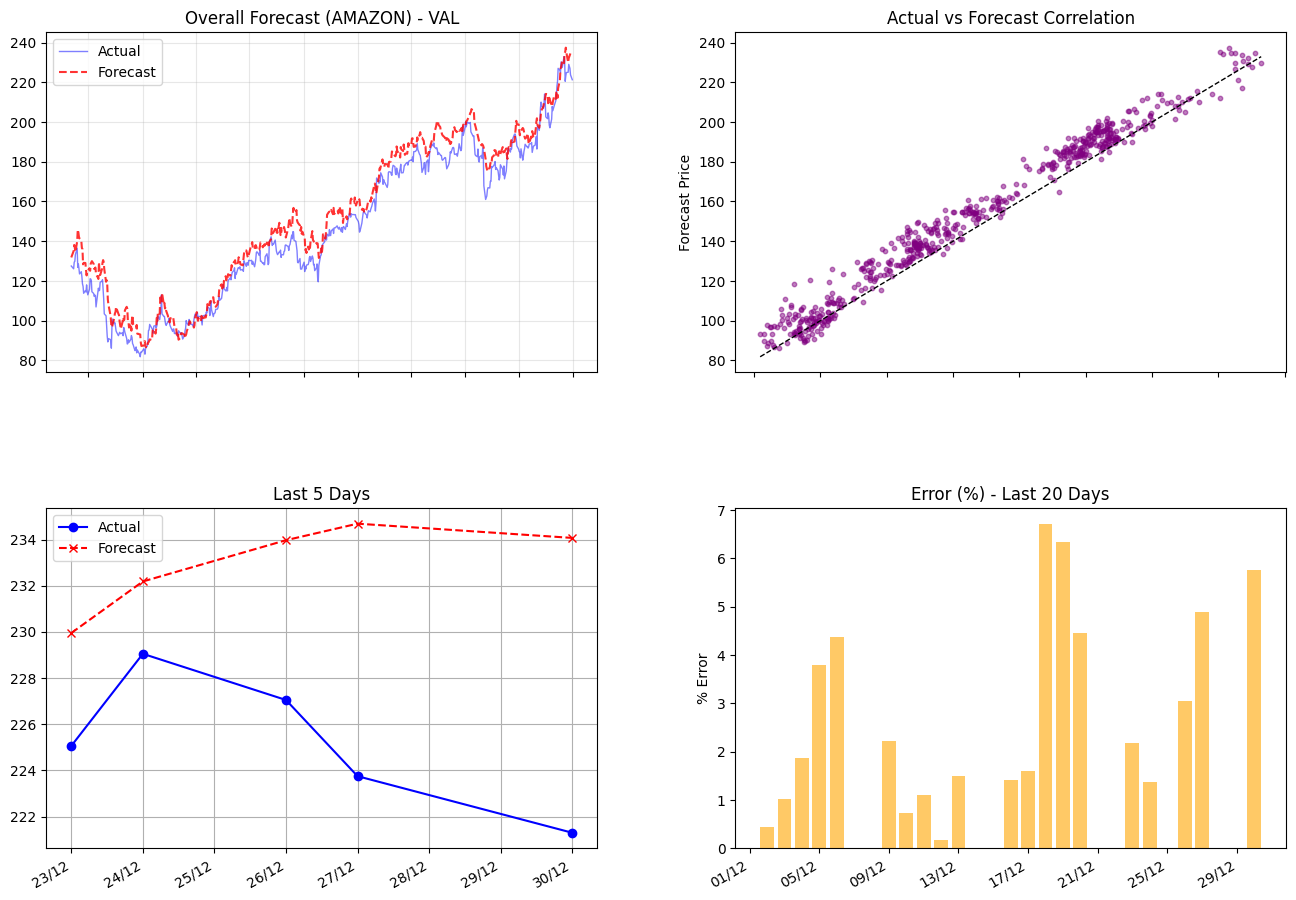

    Metrics: R2=0.9462, RMSE=8.8436

  Processing: APPLE (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2023' '04/10/2023' '04/10/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 251 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment

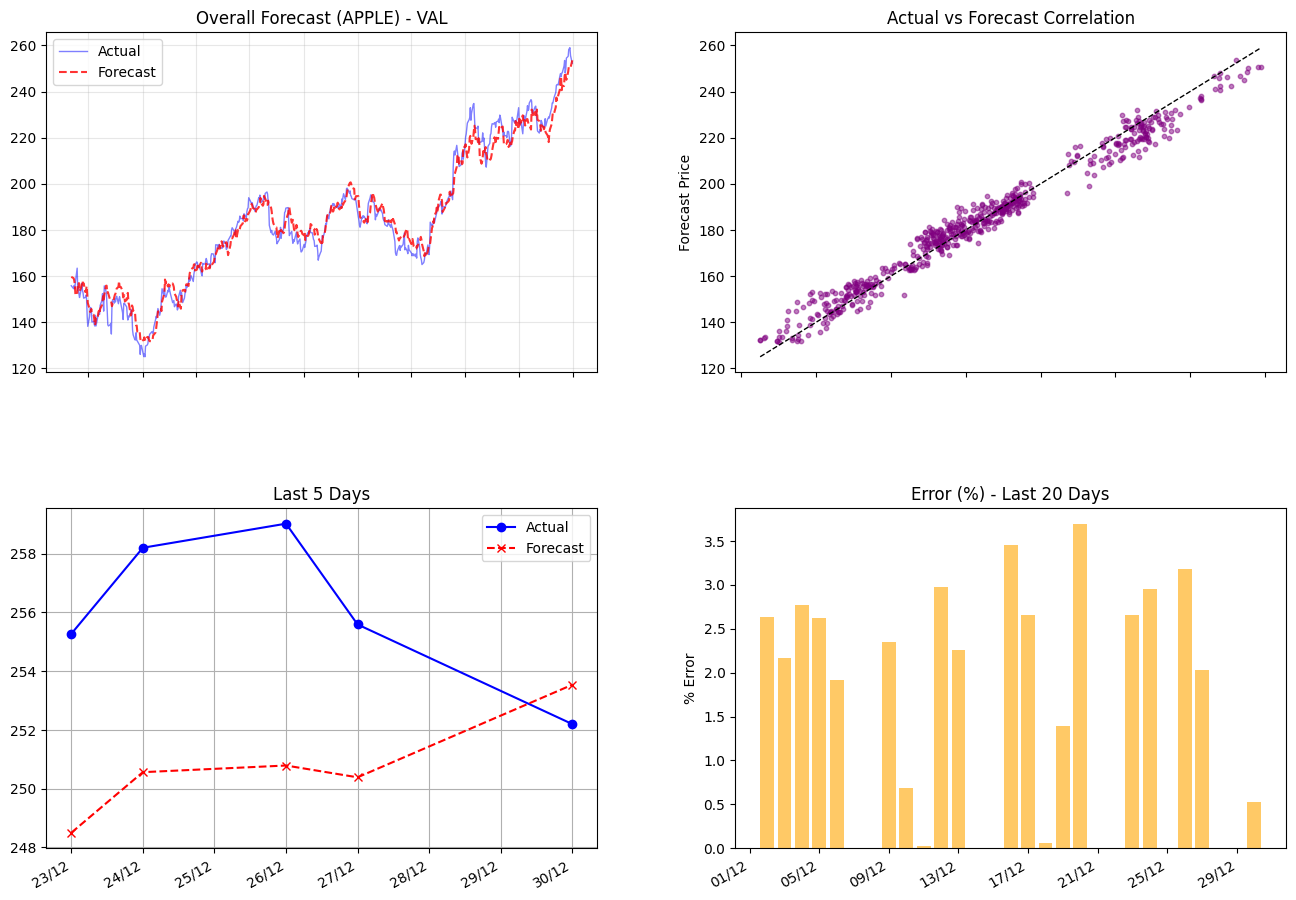

    Metrics: R2=0.9721, RMSE=5.0398

  Processing: GOOGLE (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/03/2022' '02/03/2022' '02/03/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend', 'Unnamed: 12', 'Unnamed: 13']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 419 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', '

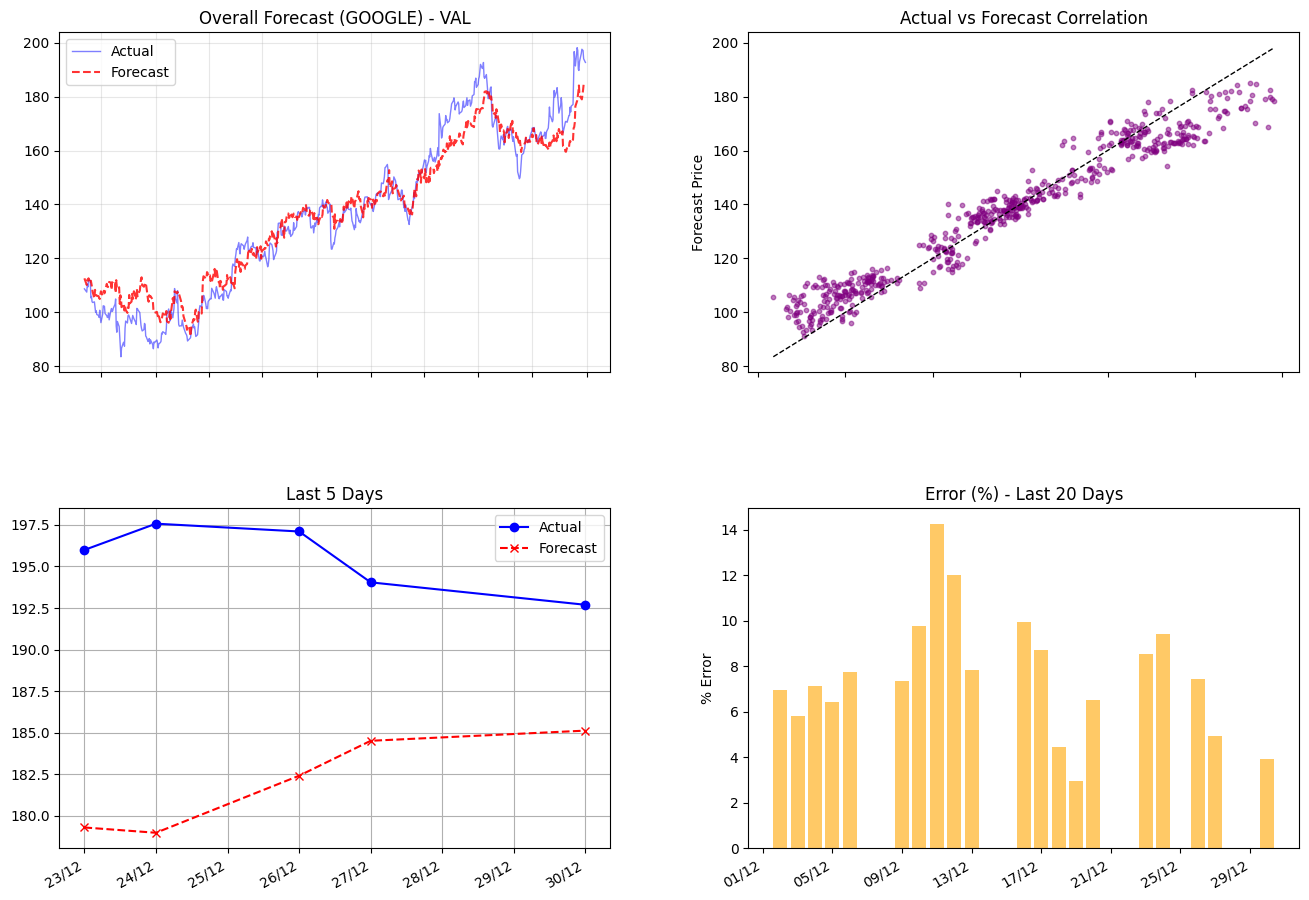

    Metrics: R2=0.9324, RMSE=7.8578

  Processing: META (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['12/07/2022' '12/07/2022' '12/07/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 622 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_

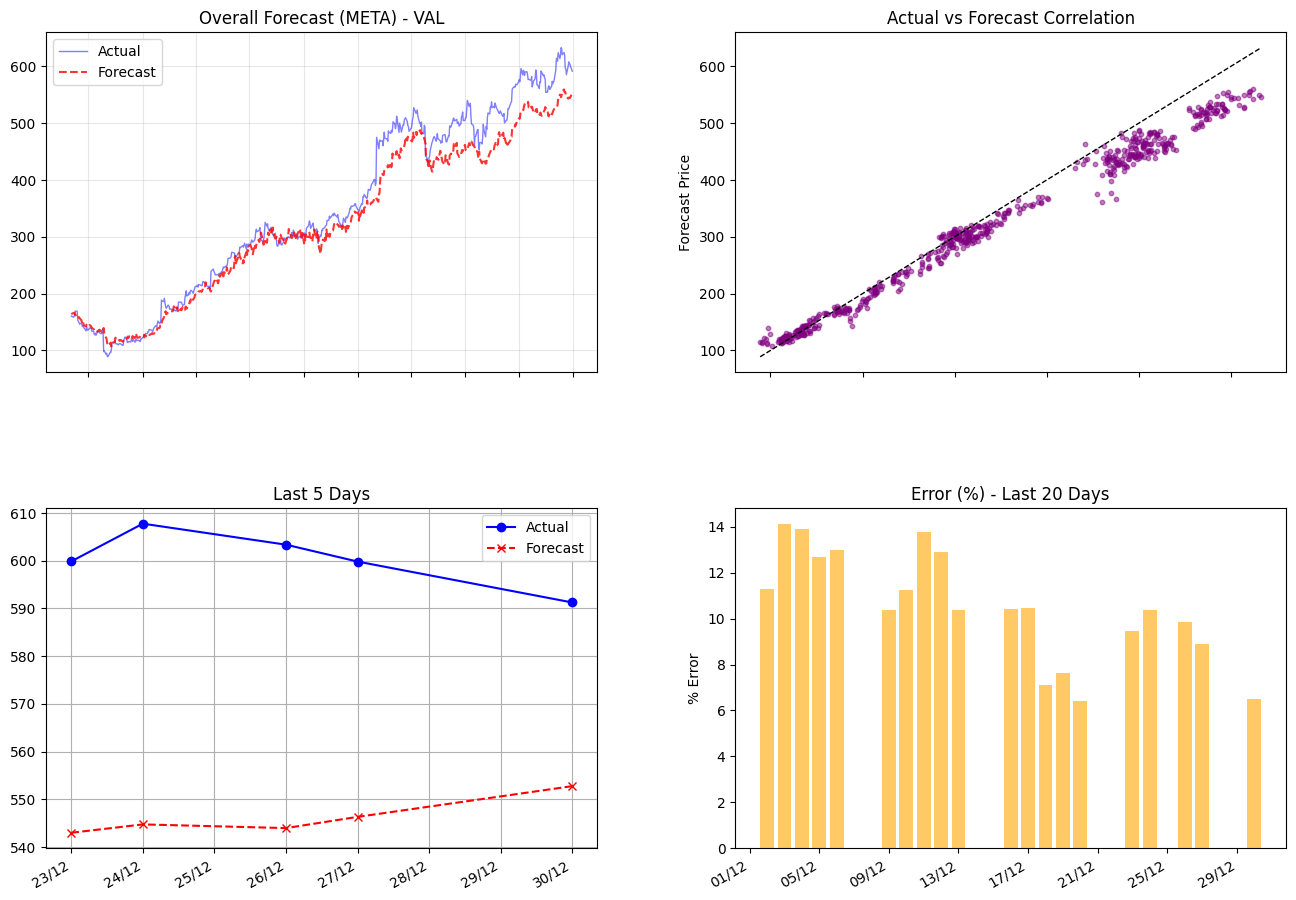

    Metrics: R2=0.9495, RMSE=35.4062

  Processing: VNM (dlinear)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2021' '05/10/2021' '05/10/2021']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 845 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_

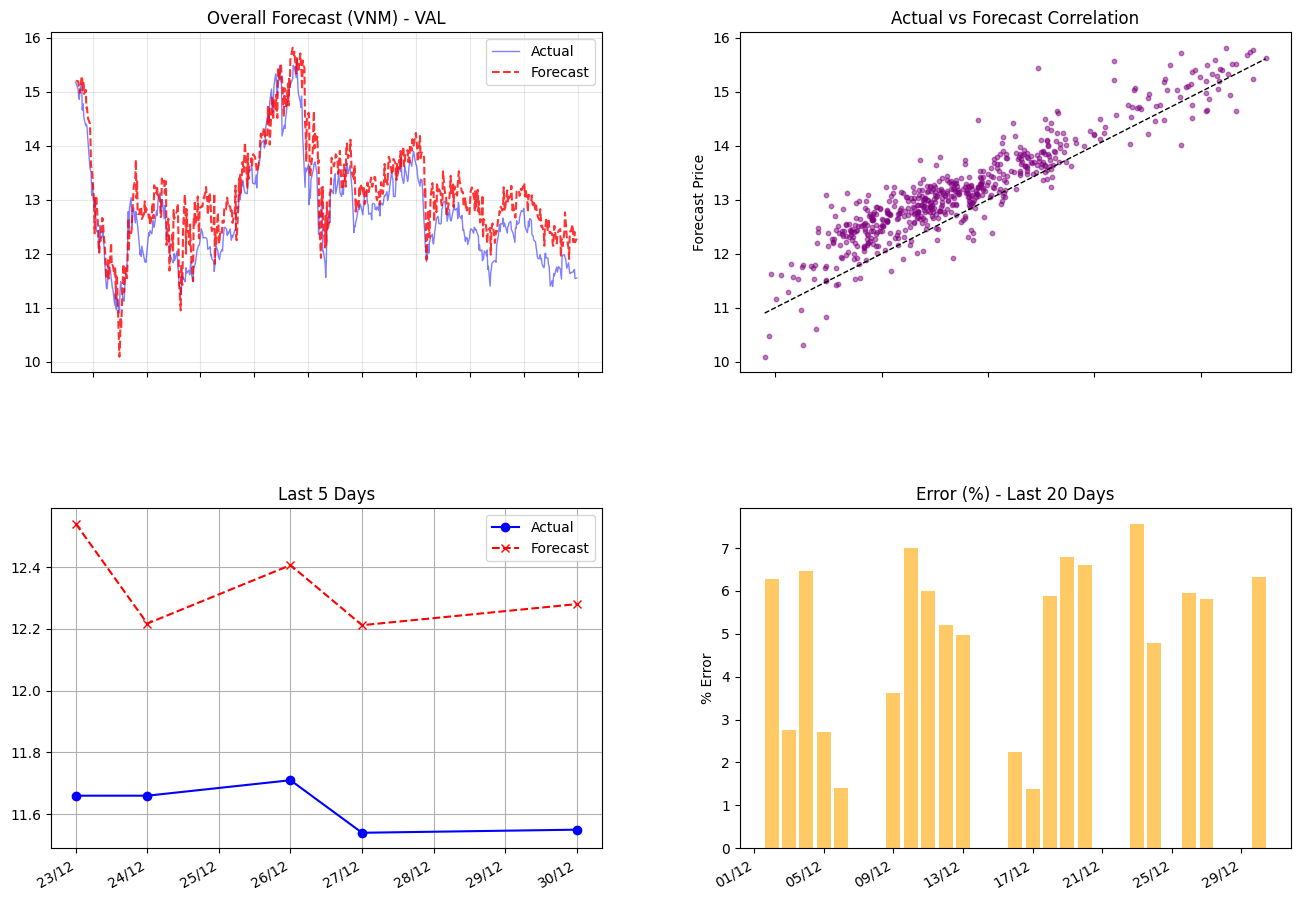

    Metrics: R2=0.6715, RMSE=0.5487

────────────────────────────────────────────────────────────────────────────────
MODEL TYPE: NODE
────────────────────────────────────────────────────────────────────────────────
Found 6 training files

  Processing: ALIBABA (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['19/09/2014' '22/09/2014' '23/09/2014']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['01/01/1970' '01/01/1970' '01/01/1970']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 2587 dòn

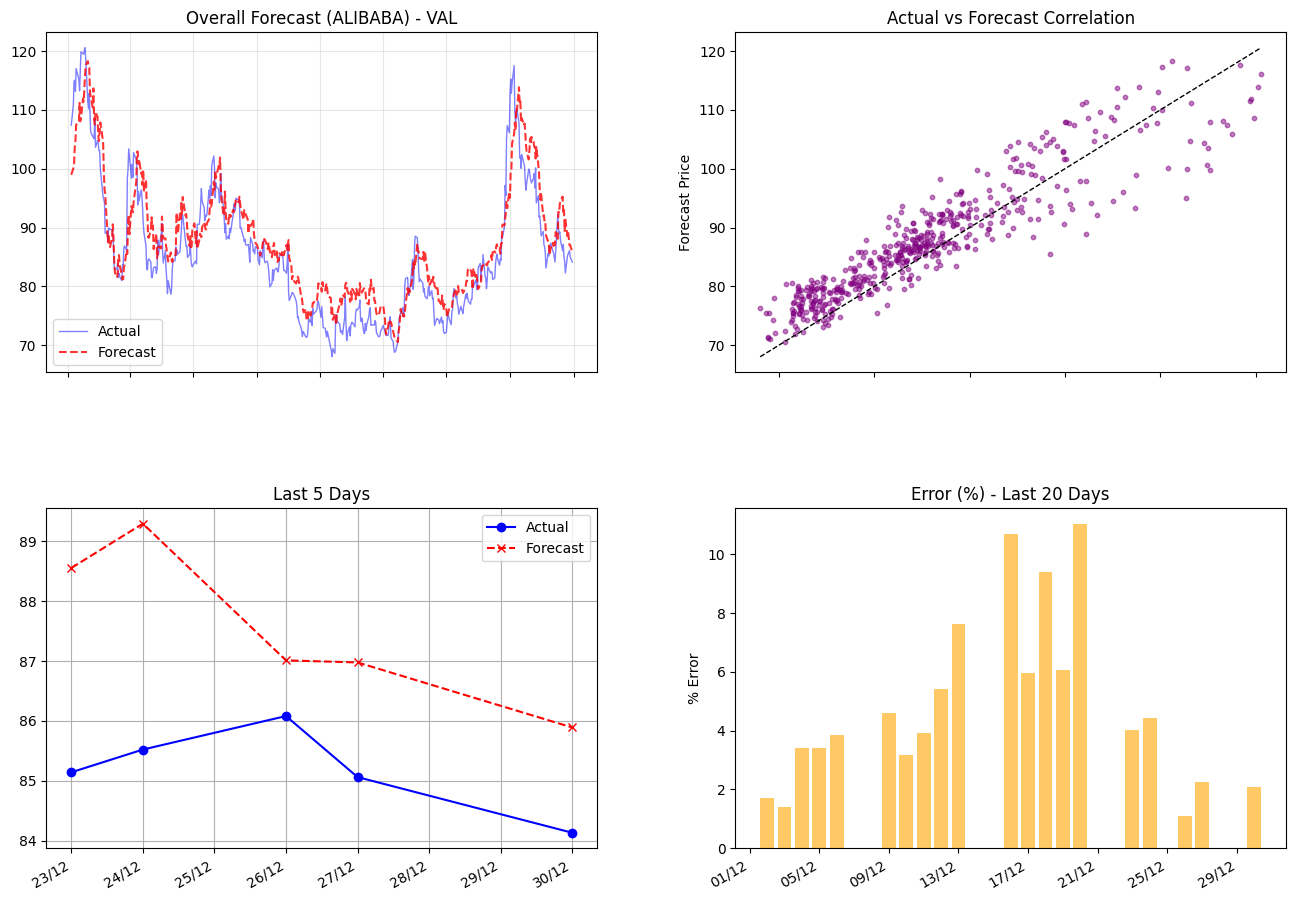

    Metrics: R2=0.8117, RMSE=4.8642

  Processing: AMAZON (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['05/08/2023' '05/08/2023' '05/08/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 718 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_v

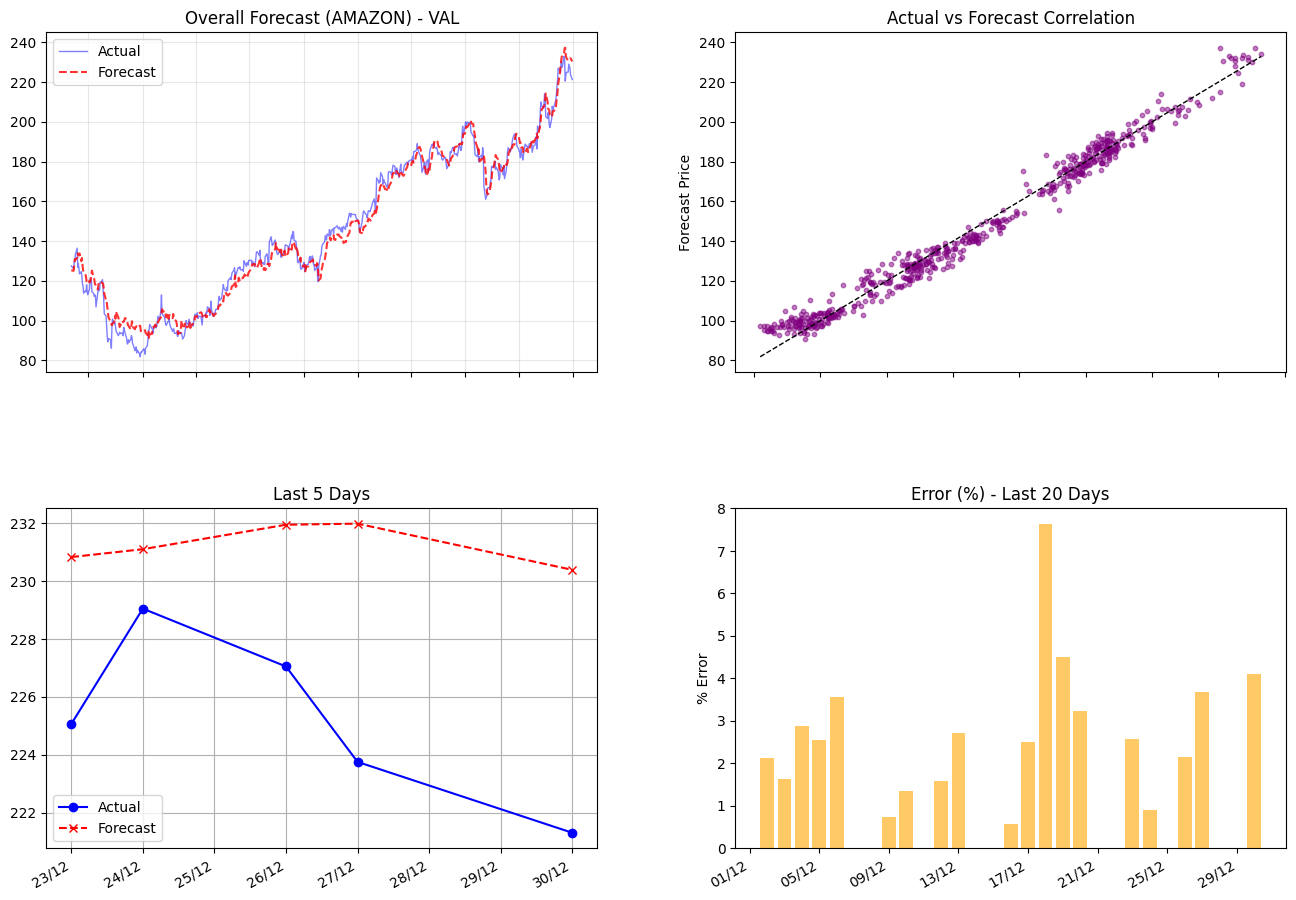

    Metrics: R2=0.9809, RMSE=5.2693

  Processing: APPLE (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2023' '04/10/2023' '04/10/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 251 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_vo

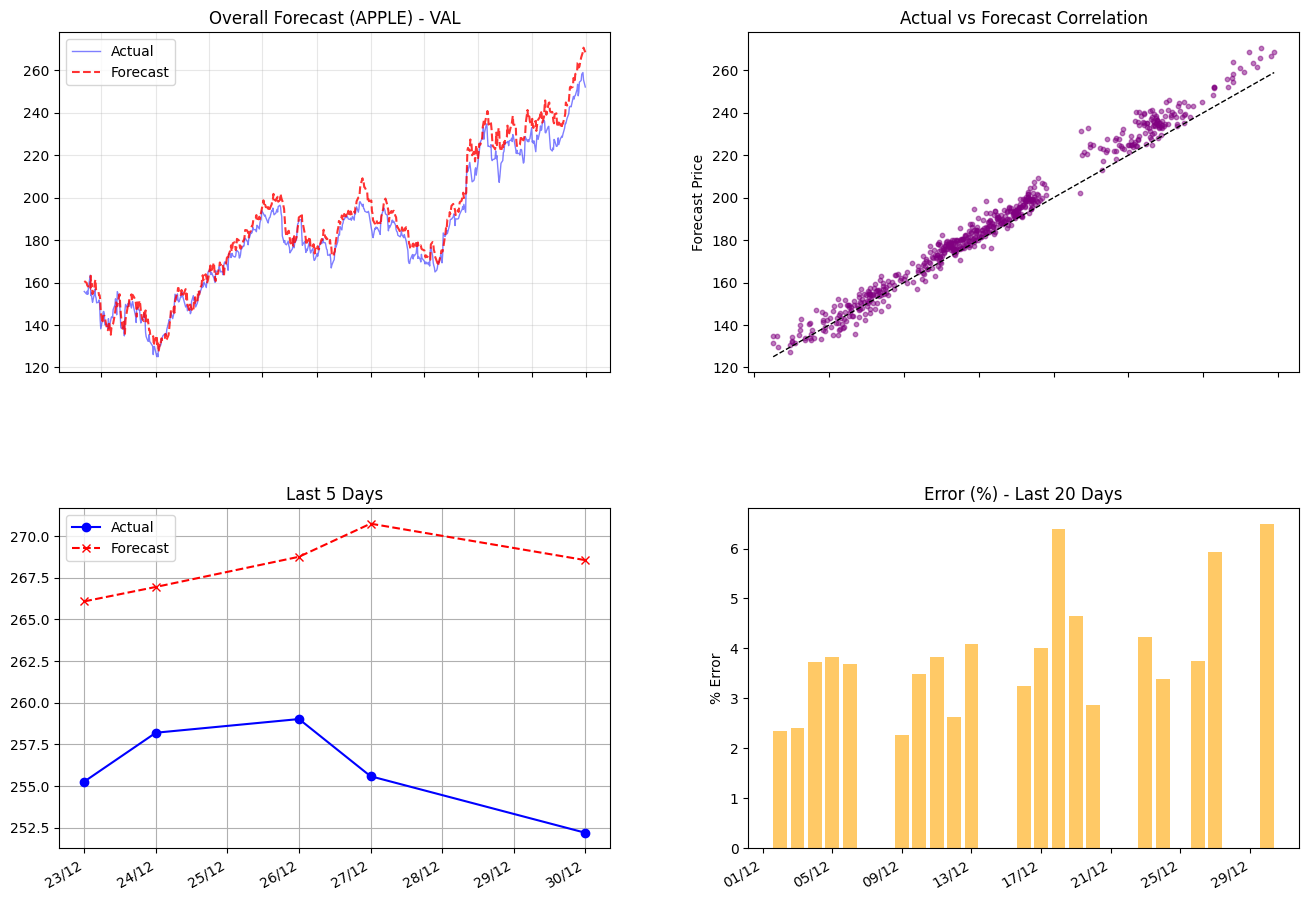

    Metrics: R2=0.9561, RMSE=6.3225

  Processing: GOOGLE (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/03/2022' '02/03/2022' '02/03/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend', 'Unnamed: 12', 'Unnamed: 13']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 419 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sen

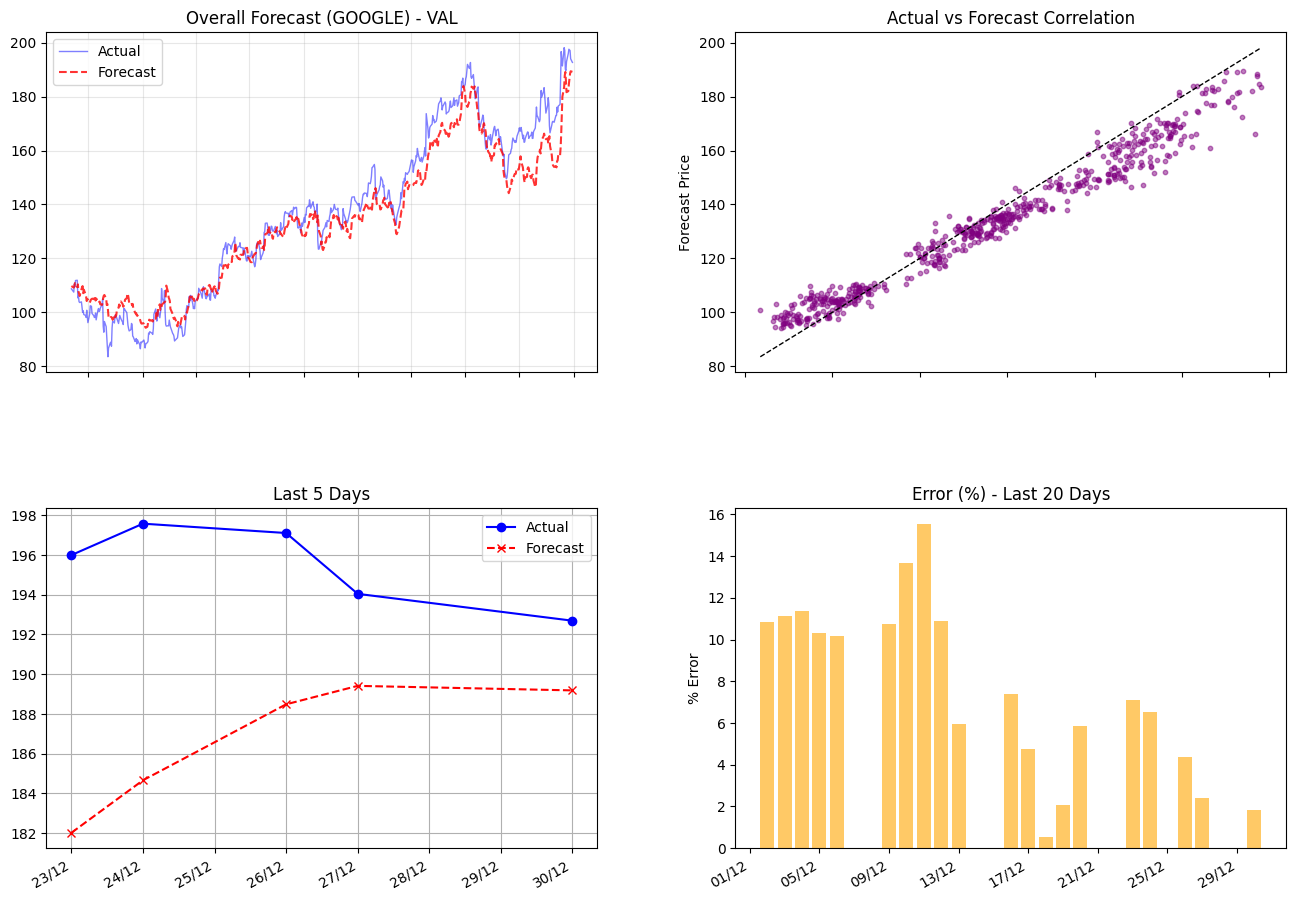

    Metrics: R2=0.9314, RMSE=7.9180

  Processing: META (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['12/07/2022' '12/07/2022' '12/07/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 622 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_vol

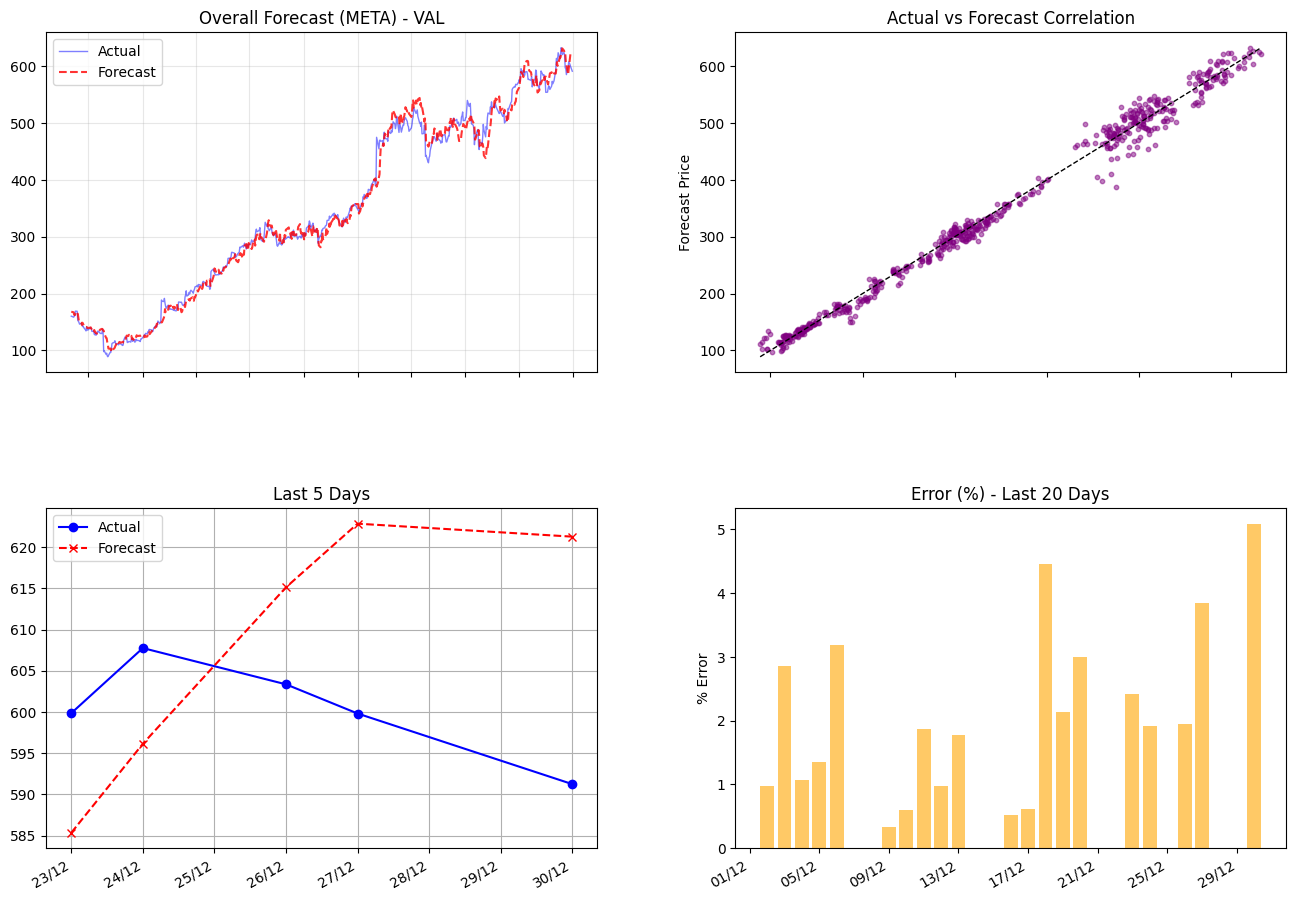

    Metrics: R2=0.9901, RMSE=15.6320

  Processing: VNM (node)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2021' '05/10/2021' '05/10/2021']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 845 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_vol

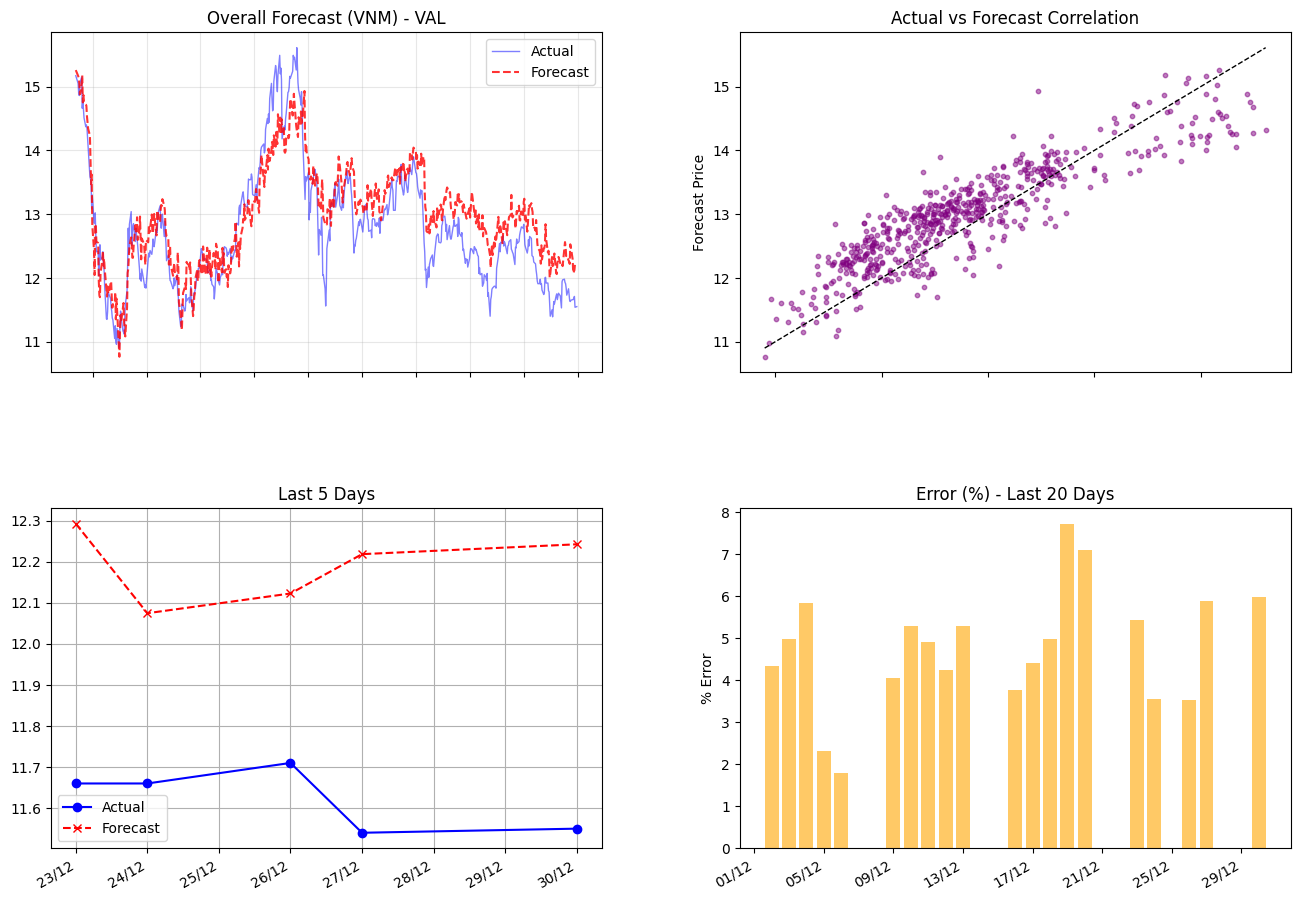

    Metrics: R2=0.7351, RMSE=0.4927

────────────────────────────────────────────────────────────────────────────────
MODEL TYPE: HYBRID
────────────────────────────────────────────────────────────────────────────────
Found 6 training files

  Processing: ALIBABA (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['19/09/2014' '22/09/2014' '23/09/2014']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['01/01/1970' '01/01/1970' '01/01/1970']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 2587

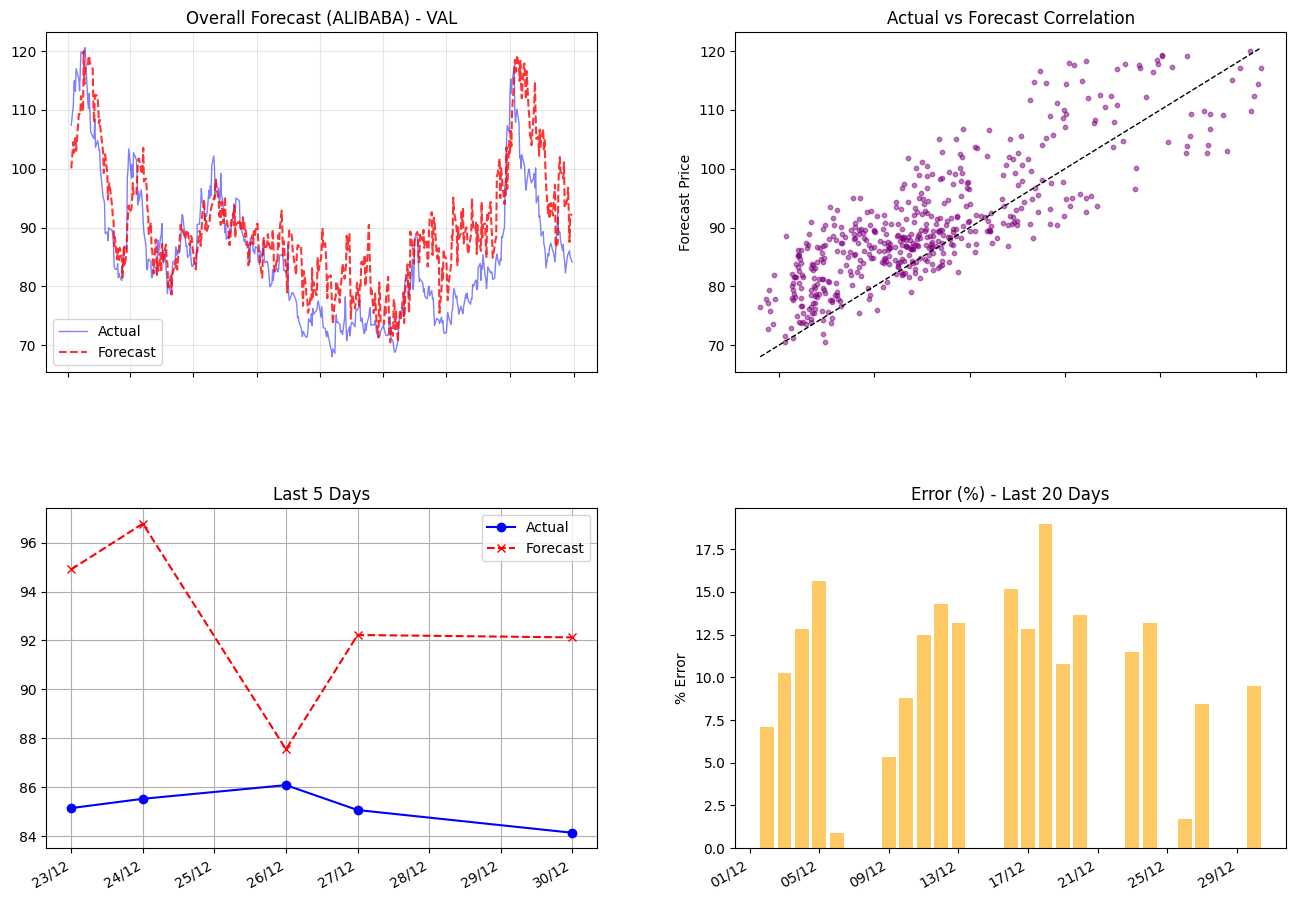

    Metrics: R2=0.5105, RMSE=7.8432

  Processing: AMAZON (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['05/08/2023' '05/08/2023' '05/08/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 718 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment

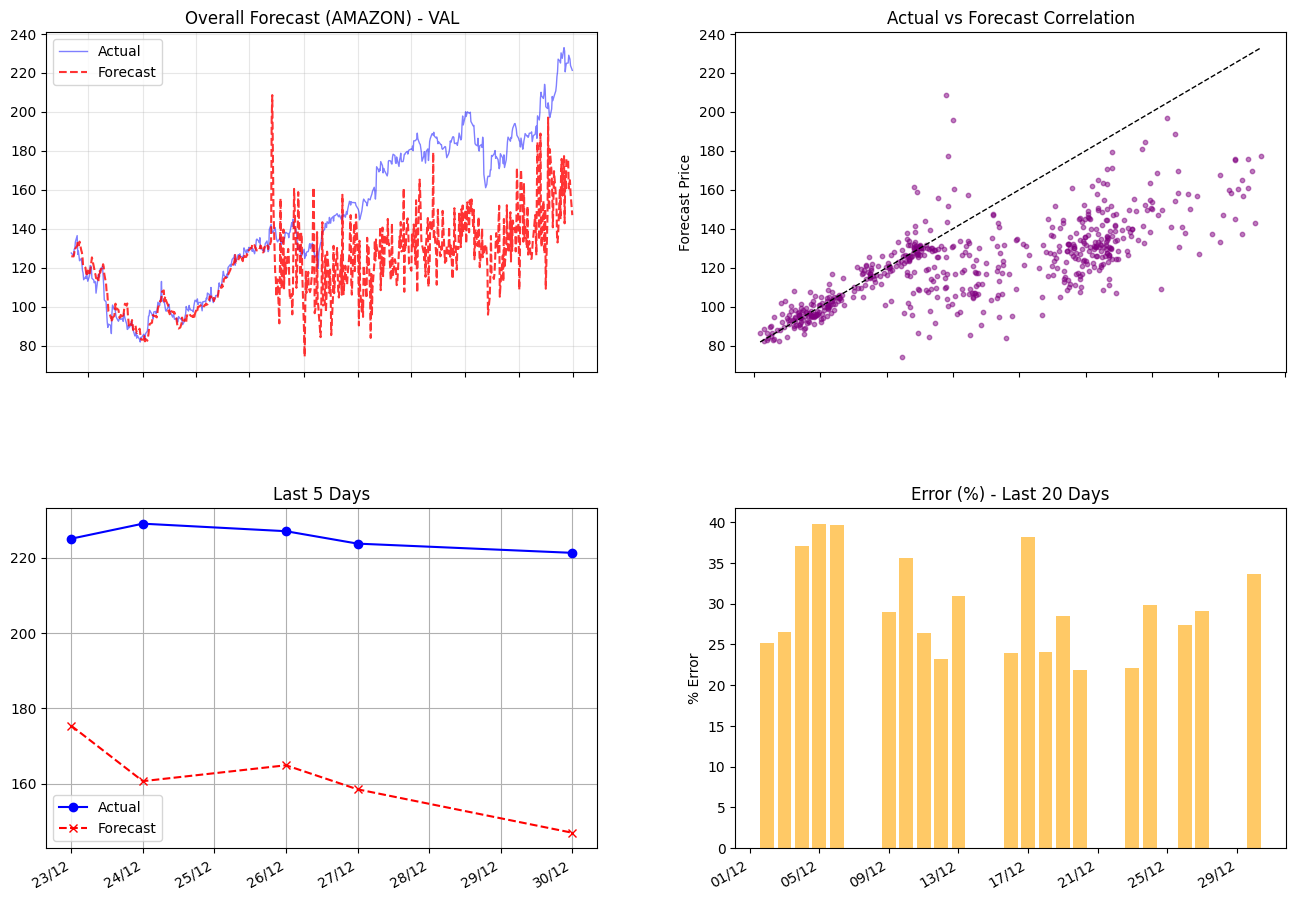

    Metrics: R2=0.0978, RMSE=36.2089

  Processing: APPLE (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2023' '04/10/2023' '04/10/2023']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 251 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment

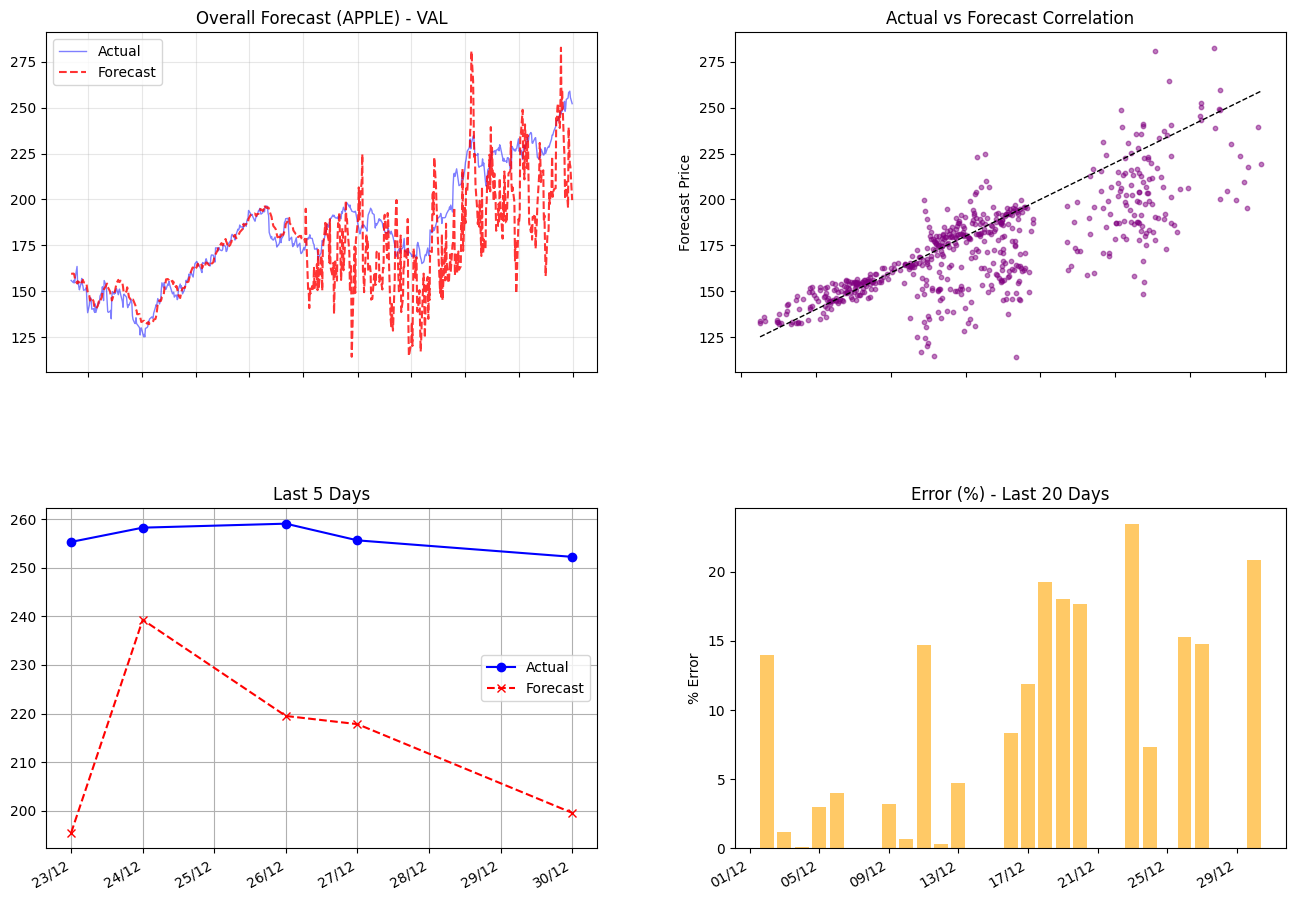

    Metrics: R2=0.4682, RMSE=21.9935

  Processing: GOOGLE (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/03/2022' '02/03/2022' '02/03/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend', 'Unnamed: 12', 'Unnamed: 13']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 419 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', '

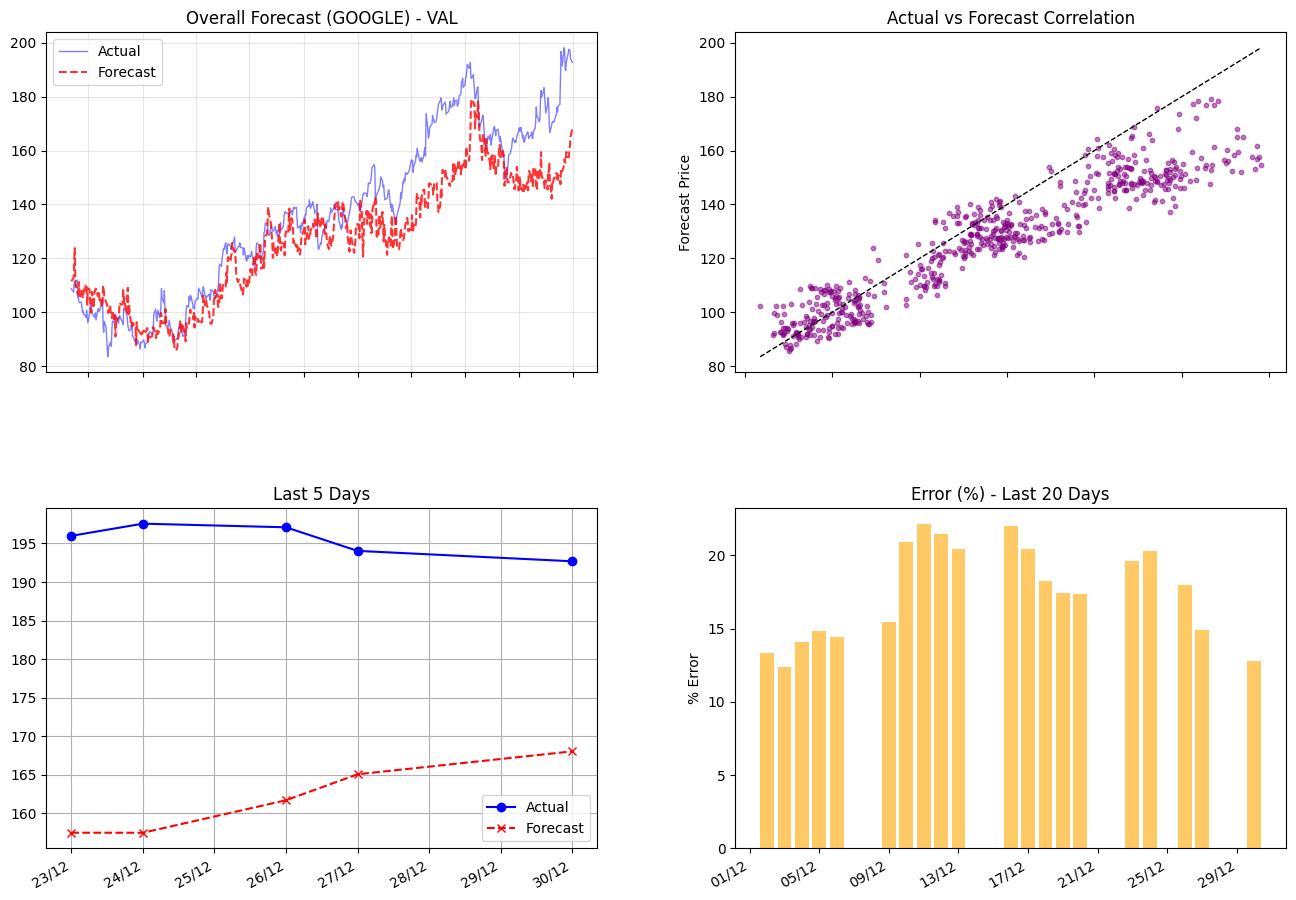

    Metrics: R2=0.7550, RMSE=14.9615

  Processing: META (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['12/07/2022' '12/07/2022' '12/07/2022']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 622 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_

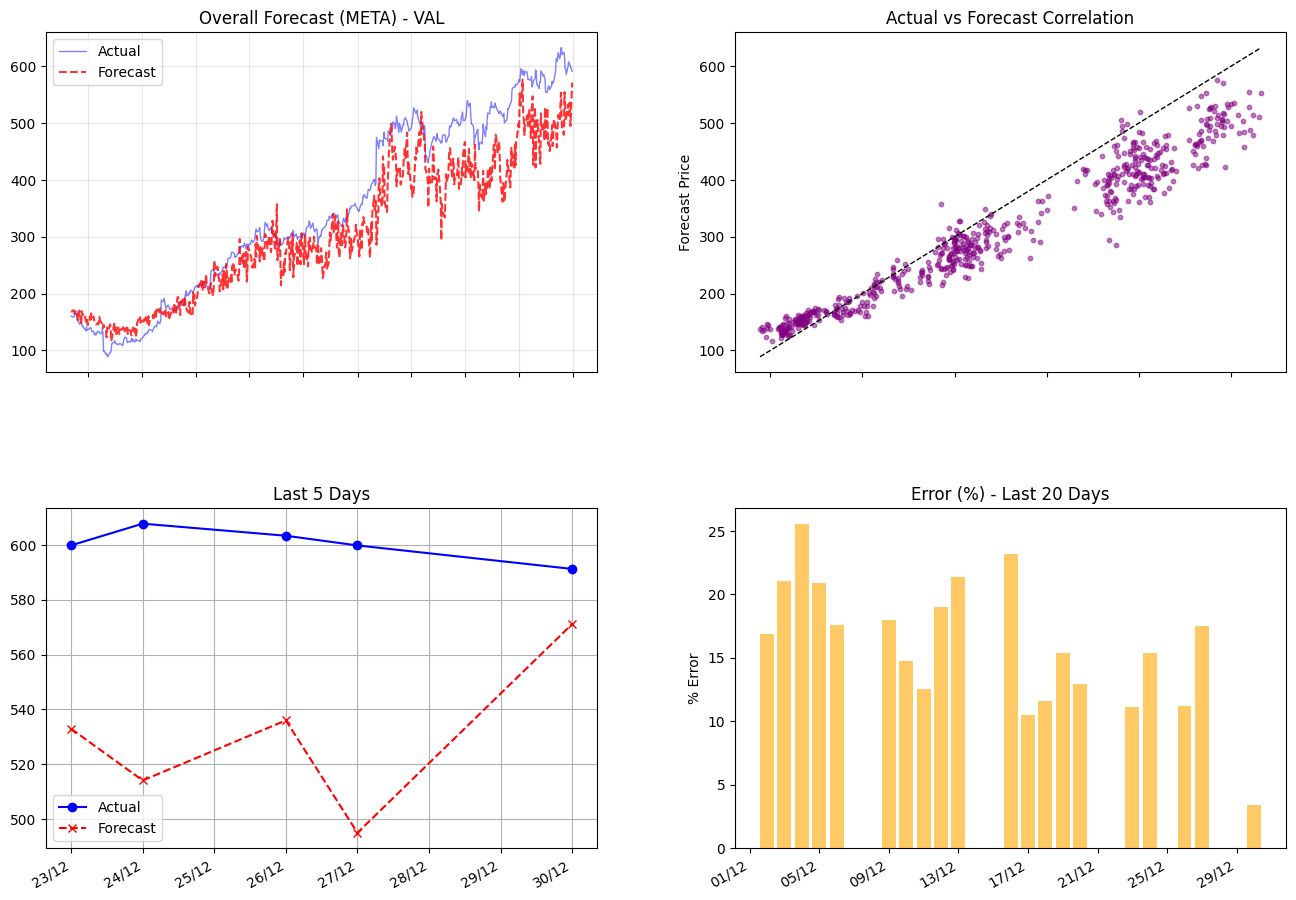

    Metrics: R2=0.8420, RMSE=62.6067

  Processing: VNM (hybrid)...
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['02/01/2013' '03/01/2013' '04/01/2013']
    [DATE] Standardized to DD/MM/YYYY format
    [DATE] Sample dates: ['04/10/2021' '05/10/2021' '05/10/2021']
    [DEBUG] Sentiment columns found in raw file: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
    [DEBUG] All sentiment columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
 THỐNG KÊ FILE GỐC:
   Price     : 3019 dòng
   Sentiment : 845 dòng
   Sentiment columns after merge: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_v

In [ ]:
# ═════════════════════════════════════════════════════════════════
# TRAIN LOOP: Iterate Models × Tickers
# ═════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STARTING TRAIN PHASE")
print("="*80)

all_metrics = []
predictions_by_ticker = {}  # {ticker: {model_type: predictions}}
processors_by_ticker = {}   # {ticker: {model_type: processor}}
os.makedirs(LOG_DIR, exist_ok=True)

for model_type in MODEL_TYPES:
    print(f"\n{'─'*80}")
    print(f"MODEL TYPE: {model_type.upper()}")
    print(f"{'─'*80}")
    
    # Get filtered training files for this model
    train_files = sorted(glob.glob(os.path.join(TRAIN_PRICE_DIR, "*.csv")))
    print(f"Found {len(train_files)} training files")
    
    for price_file in train_files:
        filename = os.path.basename(price_file)
        ticker_core = filename.replace('.csv', '')
        print(f"\n  Processing: {ticker_core} ({model_type})...")
        
        # ──────────────────────
        # LOAD & MERGE DATA
        # ──────────────────────
        # Try to load sentiment file with numeric features (name pattern: {ticker}_sentiment.csv)
        sentiment_file = os.path.join(TRAIN_SENTIMENT_DIR, f"{ticker_core}_sentiment.csv")
        if not os.path.exists(sentiment_file):
            # Fallback: try without _sentiment suffix (for backwards compatibility)
            sentiment_file = os.path.join(TRAIN_SENTIMENT_DIR, filename)
        if not os.path.exists(sentiment_file):
            print(f"    [SKIP] Sentiment file not found: {sentiment_file}")
            continue
        
        processor = DataProcessor()
        df_merged = processor.load_and_merge_data(price_file, sentiment_file)
        
        if len(df_merged) < SEQ_LEN + 50:
            print(f"    [SKIP] Insufficient data: {len(df_merged)} rows")
            continue
        
        # ──────────────────────
        # CREATE FEATURES
        # ──────────────────────
        price_feats, sent_feats, targets = processor.create_features(df_merged)
        
        # ──────────────────────
        # PREPARE SEQUENCES
        # ──────────────────────
        X_p, X_s, y = processor.prepare_sequences(
            price_feats, sent_feats, targets, 
            stock_name=ticker_core, seq_len=SEQ_LEN, fit=True
        )
        
        # Convert to tensors
        X_p_tensor = torch.from_numpy(X_p).float()
        X_s_tensor = torch.from_numpy(X_s).float()
        y_tensor   = torch.from_numpy(y).float()
        
        # Train/Val Split (80/20)
        train_size = int(0.8 * len(X_p))
        X_p_tr, X_s_tr, y_tr = X_p_tensor[:train_size], X_s_tensor[:train_size], y_tensor[:train_size]
        X_p_vl, X_s_vl, y_vl = X_p_tensor[train_size:], X_s_tensor[train_size:], y_tensor[train_size:]
        
        print(f"    Train size: {len(X_p_tr)}, Val size: {len(X_p_vl)}")
        
        # ✅ FIX: For DLinear & NODE models, use ZERO sentiment data (price-only)
        if model_type in ['dlinear', 'node']:
            X_s_tr = torch.zeros_like(X_s_tr)
            X_s_vl = torch.zeros_like(X_s_vl)
            print(f"    [INFO] {model_type.upper()}: Training with ZERO sentiment data (price-only model)")
        
        # ──────────────────────
        # CREATE & TRAIN MODEL
        # ──────────────────────
        model = get_model_by_type(
            model_type,
            seq_len=SEQ_LEN,
            price_dim=X_p.shape[2],
            sentiment_dim=X_s.shape[2],
            hidden_dim=SENTIMENT_HIDDEN_DIM,
            dropout=SENTIMENT_DROPOUT
        ).to(DEVICE)
        
        # TEN MODEL RO RANG HON
        model_name_map = {
            'dlinear': 'DLinear_PriceOnly',
            'node': 'NODE_PriceOnly',
            'hybrid': 'Hybrid_WithSentiment'
        }
        model_display_name = model_name_map[model_type]
        model_save_name = f"{ticker_core}_{model_display_name}"
        
        history, saved_path = train_model(
            model,
            DataLoader(TensorDataset(X_p_tr, X_s_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True),
            DataLoader(TensorDataset(X_p_vl, X_s_vl, y_vl), batch_size=BATCH_SIZE),
            model_save_name,
            epochs=SENTIMENT_EPOCHS,
            is_sentiment=True,
            learning_rate=SENTIMENT_LEARNING_RATE
        )
        
        # ──────────────────────
        # SAVE SCALER
        # ──────────────────────
        scaler_path = os.path.join(LOG_DIR, f"{model_save_name}_scaler.pkl")
        with open(scaler_path, 'wb') as f:
            pickle.dump({
                'price_scaler': processor.price_scaler,
                'sentiment_scaler': processor.sentiment_scaler,
                'target_scaler': processor.target_scaler
            }, f)
        print(f"  Scaler saved -> {scaler_path}")
        
        # ──────────────────────
        # VISUALIZE ON VAL SET
        # ──────────────────────
        val_dates = df_merged['Date'].tail(len(y_vl)).values
        metrics_dict = visualize_prediction(
            model, X_p_vl, X_s_vl, y_vl,
            ticker_core, val_dates, 'VAL',
            filename, processor
        )
        # Add model type to identify which model this result belong to
        model_name_display = {
            'dlinear': 'DLinear_PriceOnly',
            'node': 'NODE_PriceOnly',
            'hybrid': 'Hybrid_WithSentiment'
        }
        metrics_dict['Model'] = model_name_display[model_type]
        all_metrics.append(metrics_dict)
        print(f"    Metrics: R2={metrics_dict['R2']:.4f}, RMSE={metrics_dict['RMSE']:.4f}")
        
        # ──────────────────────
        # LƯU PREDICTIONS CHO BIỂU ĐỒ SO SÁNH
        # ──────────────────────
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_p_vl.to(DEVICE), X_s_vl.to(DEVICE)).squeeze().cpu().numpy()
            predictions = processor.target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        
        if ticker_core not in predictions_by_ticker:
            predictions_by_ticker[ticker_core] = {}
            processors_by_ticker[ticker_core] = {}
        
        predictions_by_ticker[ticker_core][model_type] = predictions
        processors_by_ticker[ticker_core][model_type] = processor
        
        # Lưu val_dates cho ticker này (tất cả model dùng chung dates)
        if 'val_dates' not in predictions_by_ticker[ticker_core]:
            predictions_by_ticker[ticker_core]['val_dates'] = val_dates
            predictions_by_ticker[ticker_core]['y_actual'] = processor.target_scaler.inverse_transform(y_vl.cpu().numpy().reshape(-1, 1)).flatten()

# ──────────────────────
# EXPORT SUMMARY
# ──────────────────────
if all_metrics:
    summary_df = pd.DataFrame(all_metrics)
    summary_path = os.path.join(LOG_DIR, "train_summary.csv")
    summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
    print(f"\n[SUCCESS] Train Summary saved -> {summary_path}")
    print(summary_df.to_string())
else:
    print("\n[ERROR] No metrics collected!")

## CELL 6: Comparison Charts - 3 Models vs Actual Price


CREATING 6 COMPARISON CHARTS

Generating charts for 6 tickers: ['ALIBABA', 'AMAZON', 'APPLE', 'GOOGLE', 'META', 'VNM']

Creating comparison chart for ALIBABA...
   [SUCCESS] Saved -> ..\..\CHART\DLINEAR+NODE\ALIBABA_comparison_3models.png


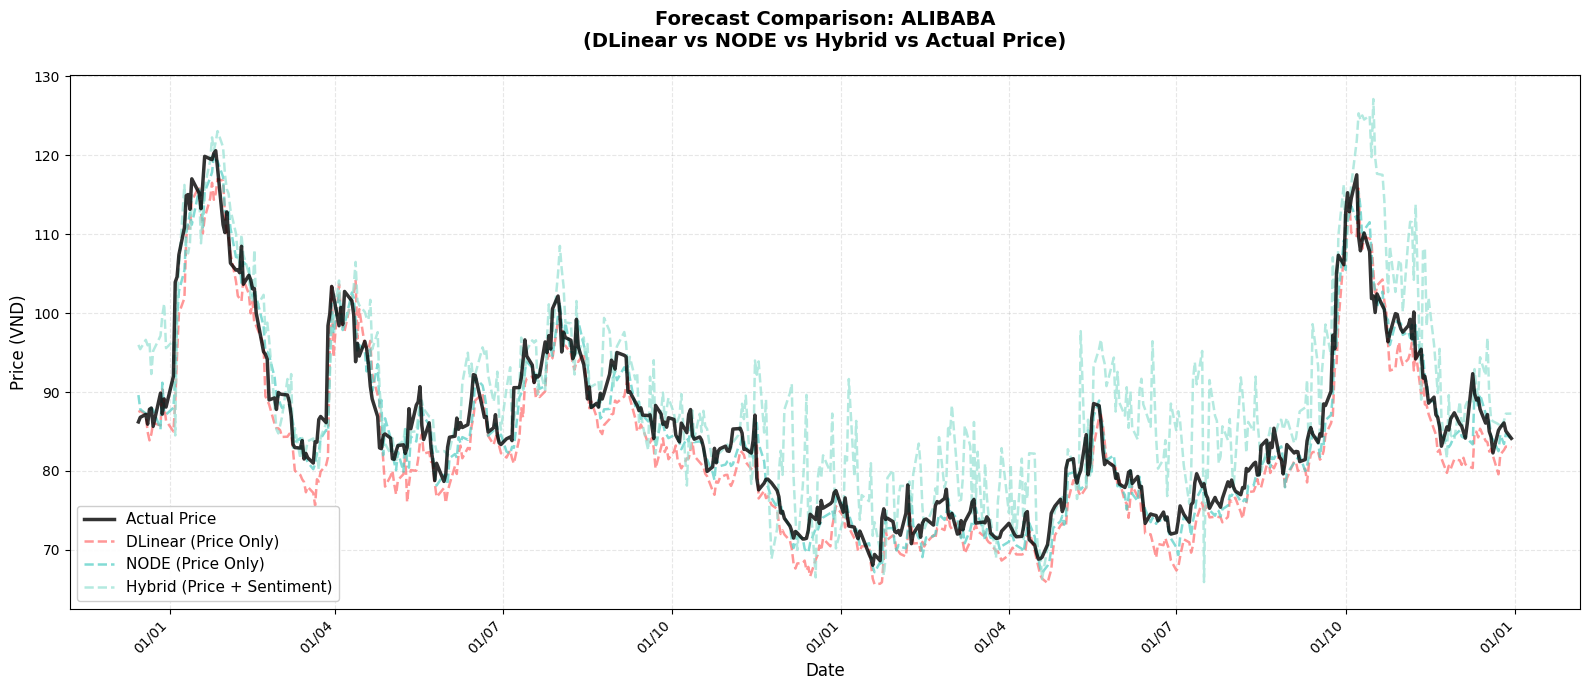

Creating comparison chart for AMAZON...


ValueError: x and y must have same first dimension, but have shapes (233,) and (598,)

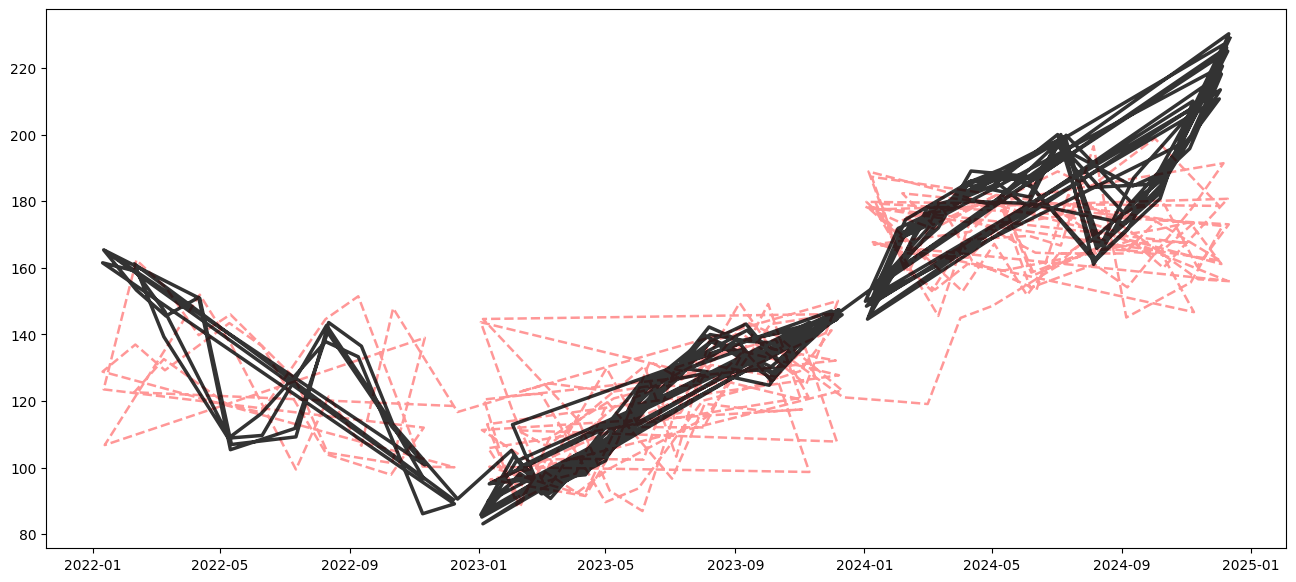

In [ ]:
# ═════════════════════════════════════════════════════════════════
# PLOT 6 COMPARISON CHARTS: DLinear vs NODE vs Hybrid vs Actual
# ═════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("CREATING 6 COMPARISON CHARTS")
print("="*80)

# Màu sắc cho mỗi mô hình
colors = {
    'dlinear': '#FF6B6B',      # Đỏ
    'node': '#4ECDC4',         # Cyan
    'hybrid': '#95E1D3',       # Xanh nhạt
    'actual': '#000000'        # Đen - Thực tế
}

model_labels = {
    'dlinear': 'DLinear (Price Only)',
    'node': 'NODE (Price Only)',
    'hybrid': 'Hybrid (Price + Sentiment)',
}

tickers_list = sorted(list(predictions_by_ticker.keys()))
print(f"\nGenerating charts for {len(tickers_list)} tickers: {tickers_list}\n")

for ticker in tickers_list:
    print(f"Creating comparison chart for {ticker}...")
    
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Lấy dates và actual prices
    val_dates = predictions_by_ticker[ticker]['val_dates']
    y_actual = predictions_by_ticker[ticker]['y_actual']
    plot_dates = pd.to_datetime(val_dates)
    
    # Plot actual price
    ax.plot(plot_dates, y_actual, label='Actual Price', 
            color=colors['actual'], linewidth=2.5, alpha=0.8, zorder=5)
    
    # Plot 3 models
    for model_type in ['dlinear', 'node', 'hybrid']:
        if model_type in predictions_by_ticker[ticker]:
            preds = predictions_by_ticker[ticker][model_type]
            ax.plot(plot_dates, preds, label=model_labels[model_type],
                    color=colors[model_type], linewidth=1.8, alpha=0.7, linestyle='--')
    
    # Formatting
    ax.set_title(f'Forecast Comparison: {ticker}\n(DLinear vs NODE vs Hybrid vs Actual Price)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (VND)', fontsize=12)
    ax.legend(loc='best', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # X-axis formatting
    date_fmt = mdates.DateFormatter('%d/%m')
    ax.xaxis.set_major_formatter(date_fmt)
    fig.autofmt_xdate(rotation=45, ha='right')
    
    # Tight layout
    plt.tight_layout()
    
    # Save chart
    chart_filename = f"{ticker}_comparison_3models.png"
    chart_path = os.path.join(CHART_DIR, chart_filename)
    plt.savefig(chart_path, bbox_inches='tight', dpi=150)
    print(f"   [SUCCESS] Saved -> {chart_path}")
    
    plt.show()
    plt.close(fig)

print(f"\n[SUCCESS] ALL {len(tickers_list)} COMPARISON CHARTS CREATED!")